## Attempt

I attempted to work with PCA to reduce dimensionality with my created features post-aggregation. These features are the general summary statistics for amount and include some date-related measures. After standard scaling variables, I implemented an XGBoost model with a base score of 0.5 and log loss function.

In addition, I created a function that compares the correlation between these variables and FPF_TARGET; I also calculate the mean of these variables by FPF_TARGET label.

## Main Findings

- PCA may not exactly be the right for this model; it reduced my baseline model accuracy down to 50%. This can be due to limited data, however. More testing will need to be done to determine whether or not I will continue to work with PCA.

- mean_pos_amount, range_date_posted, first_date_posted, max_amount, fin_balance, mean_date_posted have the highest correlation to FPF_TARGET. This can indicate that these variables are quite helpful in differentiating between the FPF_TARGET labels.

- There are noticeable differences in variables means between the two FPF_TARGET labels for the following variables: total_amount, fin_balance, total_pos_amount, mean_neg_amount, mean_amount, min_amount, max_amount, range_date_posted, date_mean_median_diff_posted. Again, this can indicate that these variables are quite helpful in differentiating between the FPF_TARGET labels.

- This baseline model achieves an accuracy on the sample data of ~60%--slightly better than guessing. My next steps are with optimization to improve the model to hopefully achieve the baseline accuracy of 90%....

In [2]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from abc import ABC, abstractmethod
from pathlib import Path

from mlc.cashflow import ScorableModelTemplate
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


import warnings
warnings.filterwarnings("ignore")

In [3]:
def process_inputs(raw_consumer_file: str, raw_transactions_file: str):
        """Input argument will vary. See you competition's template.

        :param raw_files: list of file path strings, depends on competition
        :return: anything needed for you model to make predictions, e.g. features or processed data
        """
        # Implement this: only need to read in files for first assignment
        df_consumer = pd.read_parquet(raw_consumer_file)
        df_transactions = pd.read_parquet(raw_transactions_file)
        merged_df = df_transactions.merge(df_consumer, on = "masked_consumer_id")
        filtered_df = merged_df[merged_df["posted_date"]< merged_df["evaluation_date"]]
        
        filtered_df['evaluation_date'] = pd.to_datetime(filtered_df['evaluation_date'])
        filtered_df['evaluation_day'] = filtered_df['evaluation_date'].dt.dayofweek

        filtered_df['posted_date'] = pd.to_datetime(filtered_df['posted_date'])
        filtered_df['posted_day'] = filtered_df['posted_date'].dt.dayofweek
        
        return filtered_df
df_train = process_inputs("training_data/consumer_data.parquet", "training_data/transactions.parquet")

In [4]:
class ScorableModel(ScorableModelTemplate):

    def predict(self, raw_consumer_file: str, raw_transactions_file: str):
        """Input argument will vary. See you competition's template.

        :param raw_files: list of file path strings, depends on competition
        :return predictions: dataframe or np.array, depends on competition
        """
        # Implement this: may return random predictions for the first assignment
        df_consumers = self.process_inputs(raw_consumer_file, raw_transactions_file) #load processed features
        
        def helper(group_df):
            result = {
                'num_transactions': group_df['amount'].count(),
                'total_amount': group_df['amount'].sum(),
                'fin_balance': group_df['total_balance'].mean(),
                'total_pos_amount': group_df[group_df['amount'] > 0]['amount'].sum(),
                'total_neg_amount': group_df[group_df['amount'] < 0]['amount'].sum(),
                'mean_pos_amount': group_df[group_df['amount'] > 0]['amount'].mean(),
                'mean_neg_amount': group_df[group_df['amount'] < 0]['amount'].mean(),
                'mean_amount': group_df['amount'].mean(),
                'amount_mean_median_diff': group_df['amount'].mean() - group_df['amount'].median(),
                'min_amount': group_df['amount'].min(),
                'max_amount': group_df['amount'].max(),
                'common_category': group_df['category'].mode()[0],
                'date': group_df['evaluation_date'].min().timestamp(),
                'first_date_posted': group_df['posted_date'].min().timestamp(),
                'last_date_posted': group_df['posted_date'].max().timestamp(),
                'range_date_posted': (group_df['posted_date'].max() - group_df['posted_date'].min()).days,
                'mode_day_posted': group_df['posted_day'].mode()[0],
                'mean_date_posted': group_df['posted_date'].mean().timestamp(),
                'date_mean_median_diff_posted': (group_df['posted_date'].mean() - group_df['posted_date'].median()).days,
                'FPF_TARGET': group_df['FPF_TARGET'].mean()
            }
            if len(group_df[group_df['amount'] > 0]) == 0:
                result['total_pos_amount'] = 0
                result['mean_pos_amount'] = 0
            elif len(group_df[group_df['amount'] < 0]) == 0:
                result['total_neg_amount'] = 0
                result['mean_neg_amount'] = 0
            return pd.Series(result)
        
        # === Step 3: Aggregate ===

        ##################################TRAINING DATA####################################
        df_train = self.process_inputs("training_data/consumer_data.parquet", "training_data/transactions.parquet") #load processed features 
        
        aggregated_train_data = df_train.groupby('masked_consumer_id').apply(helper).reset_index()
        aggregated_train_encoded = pd.get_dummies(aggregated_train_data.drop(columns=['masked_consumer_id']), drop_first=True)

        # Separate target
        train_target = aggregated_train_encoded['FPF_TARGET']
        train_features = aggregated_train_encoded.drop(columns='FPF_TARGET')

        # Standardize
        scaler = StandardScaler()
        train_features_scaled = scaler.fit_transform(train_features)
        
        # === Step 5: Run PCA ===
        pca = PCA()
        train_pca_components = pca.fit_transform(train_features_scaled)
        cumulative_var = np.cumsum(pca.explained_variance_ratio_)
        n_components_95 = np.argmax(cumulative_var >= 0.95) + 1
        
        # Create DataFrame with only the most significant components
        pca_train_df = pd.DataFrame(
            train_pca_components[:, :n_components_95],
            columns=[f'PC{i+1}' for i in range(n_components_95)]
        )
        ##################################TESTING DATA####################################
        aggregated_data = df_consumers.groupby('masked_consumer_id').apply(helper).reset_index()
        aggregated_encoded = pd.get_dummies(aggregated_data.drop(columns=['masked_consumer_id']), drop_first=True)
        
        target = aggregated_encoded['FPF_TARGET']
        features = aggregated_encoded.drop(columns='FPF_TARGET')

        features_scaled = scaler.transform(features)
        
        pca_components = pca.transform(features_scaled)
        pca_df = pd.DataFrame(
            pca_components[:, :n_components_95],
            columns=[f'PC{i+1}' for i in range(n_components_95)]
        )
        
        
        # Step 3: Initialize and train the XGBoost classifier
        model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss',base_score=0.5)
        model.fit(pca_train_df, train_target)

        # Step 4: Make predictions
        y_pred = model.predict(pca_df)
        print(f"Accuracy Test: {accuracy_score(target, y_pred):.2f}")

        return y_pred

    def process_inputs(self, raw_consumer_file: str, raw_transactions_file: str):
        """Input argument will vary. See you competition's template.

        :param raw_files: list of file path strings, depends on competition
        :return: anything needed for you model to make predictions, e.g. features or processed data
        """
        # Implement this: only need to read in files for first assignment
        df_consumer = pd.read_parquet(raw_consumer_file)
        df_transactions = pd.read_parquet(raw_transactions_file)
        merged_df = df_transactions.merge(df_consumer, on = "masked_consumer_id")
        filtered_df = merged_df[merged_df["posted_date"]< merged_df["evaluation_date"]]
        
        filtered_df['evaluation_date'] = pd.to_datetime(filtered_df['evaluation_date'])
        filtered_df['evaluation_day'] = filtered_df['evaluation_date'].dt.dayofweek

        filtered_df['posted_date'] = pd.to_datetime(filtered_df['posted_date'])
        filtered_df['posted_day'] = filtered_df['posted_date'].dt.dayofweek
        
        return filtered_df

# Intialize, runs: __check_rep__ to validate class
model = ScorableModel() # error will be raised if the above is not implemented correctly

Accuracy Test: 1.00


In [11]:
_, true_output = model.load_test_case()
predictions = model.predict("mlc/test_data/consumer_data.parquet", "mlc/test_data/transactions.parquet")

Accuracy Test: 1.00


In [5]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# === Step 1: Load and preprocess data ===
my_df = model.process_inputs("training_data/consumer_data.parquet", "training_data/transactions.parquet")

my_df['evaluation_date'] = pd.to_datetime(my_df['evaluation_date'])
my_df['evaluation_day'] = my_df['evaluation_date'].dt.dayofweek

my_df['posted_date'] = pd.to_datetime(my_df['posted_date'])
my_df['posted_day'] = my_df['posted_date'].dt.dayofweek

# === Step 2: Define aggregation helper ===
def helper(group_df):
    result = {
        'num_transactions': group_df['amount'].count(),
        'total_amount': group_df['amount'].sum(),
        'fin_balance': group_df['total_balance'].mean(),
        'total_pos_amount': group_df[group_df['amount'] > 0]['amount'].sum(),
        'total_neg_amount': group_df[group_df['amount'] < 0]['amount'].sum(),
        'mean_pos_amount': group_df[group_df['amount'] > 0]['amount'].mean(),
        'mean_neg_amount': group_df[group_df['amount'] < 0]['amount'].mean(),
        'mean_amount': group_df['amount'].mean(),
        'amount_mean_median_diff': group_df['amount'].mean() - group_df['amount'].median(),
        'min_amount': group_df['amount'].min(),
        'max_amount': group_df['amount'].max(),
        'common_category': group_df['category'].mode()[0],
        'date': group_df['evaluation_date'].min().timestamp(),
        'first_date_posted': group_df['posted_date'].min().timestamp(),
        'last_date_posted': group_df['posted_date'].max().timestamp(),
        'range_date_posted': (group_df['posted_date'].max() - group_df['posted_date'].min()).days,
        'mode_day_posted': group_df['posted_day'].mode()[0],
        'mean_date_posted': group_df['posted_date'].mean().timestamp(),
        'date_mean_median_diff_posted': (group_df['posted_date'].mean() - group_df['posted_date'].median()).days,
        'FPF_TARGET': group_df['FPF_TARGET'].mean()
    }
    if len(group_df[group_df['amount'] > 0]) == 0:
        result['total_pos_amount'] = 0
        result['mean_pos_amount'] = 0
    elif len(group_df[group_df['amount'] < 0]) == 0:
        result['total_neg_amount'] = 0
        result['mean_neg_amount'] = 0
    return pd.Series(result)

# === Step 3: Aggregate ===
aggregated_data = my_df.groupby('masked_consumer_id').apply(helper).reset_index()

# === Step 4: Encode categorical and scale ===
# Convert 'common_category' to dummy variables (one-hot encoding)
aggregated_encoded = pd.get_dummies(aggregated_data.drop(columns=['masked_consumer_id']), drop_first=True)

# Separate target
target = aggregated_encoded['FPF_TARGET']
features = aggregated_encoded.drop(columns='FPF_TARGET')

# Standardize
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# === Step 5: Run PCA ===
#pca = PCA()
#pca_components = pca.fit_transform(features_scaled)

# Create a DataFrame with principal components
#pca_df = pd.DataFrame(pca_components, columns=[f'PC{i+1}' for i in range(pca_components.shape[1])])
#pca_df['FPF_TARGET'] = target.values

# === Step 6: Correlation function ===
def correlation_with_x(df, x="FPF_TARGET"):
    if x not in df.columns:
        raise ValueError(f"{x} is not a column in the DataFrame")
    numeric_df = df.select_dtypes(include='number')
    correlation_row = numeric_df.corr().loc[x].drop(x)
    return correlation_row.to_frame(name=f'correlation_with_{x}').T

# === Step 7: Run correlation ===
correlation_result = correlation_with_x(aggregated_encoded)
print(correlation_result)

                             num_transactions  total_amount  fin_balance  \
correlation_with_FPF_TARGET         -0.156875      0.006666    -0.067335   

                             total_pos_amount  total_neg_amount  \
correlation_with_FPF_TARGET         -0.118964          0.119958   

                             mean_pos_amount  mean_neg_amount  mean_amount  \
correlation_with_FPF_TARGET        -0.112307         0.045406     0.002098   

                             amount_mean_median_diff  min_amount  max_amount  \
correlation_with_FPF_TARGET                -0.020895    0.074621   -0.087865   

                             common_category     date  first_date_posted  \
correlation_with_FPF_TARGET          -0.0762  0.16272           0.298907   

                             last_date_posted  range_date_posted  \
correlation_with_FPF_TARGET          0.165222          -0.285699   

                             mode_day_posted  mean_date_posted  \
correlation_with_FPF_TARGET         0.

In [13]:
aggregated_data.groupby('FPF_TARGET').describe().xs('mean', level=1, axis=1)

,num_transactions,total_amount,fin_balance,total_pos_amount,total_neg_amount,mean_pos_amount,mean_neg_amount,mean_amount,amount_mean_median_diff,min_amount,max_amount,common_category,date,first_date_posted,last_date_posted,range_date_posted,mode_day_posted,mean_date_posted,date_mean_median_diff_posted
FPF_TARGET,,,,,,,,,,,,,,,,,,,
0.0,1159.392801,-941.046211,7602.288067,138114.221297,-139055.267508,928.229399,-218.591948,-1.569235,24.957026,-12012.664786,17437.941773,10.928013,1.665146e+09,1.635299e+09,1.664812e+09,341.588121,0.883374,1.650628e+09,-2.285118
1.0,799.342020,-323.788823,952.547846,44110.880981,-44434.669805,319.664101,-81.649950,-0.356940,11.874948,-2655.335533,4104.578005,9.376221,1.671918e+09,1.654022e+09,1.671727e+09,204.915309,2.207655,1.663150e+09,-2.093241


In [6]:
my_df

,masked_consumer_id,posted_date,amount,category,masked_transaction_id,evaluation_date,FPF_TARGET,total_balance,evaluation_day,posted_day
0,C02103629,2022-08-12,-21.00,27.0,C02T02715977,2022-11-16,1.0,109.53,2,4
1,C02103629,2022-08-09,-8.60,22.0,C02T02715978,2022-11-16,1.0,109.53,2,1
2,C02103629,2022-08-07,-30.05,16.0,C02T02715979,2022-11-16,1.0,109.53,2,6
3,C02103629,2022-09-29,-0.46,0.0,C02T02715980,2022-11-16,1.0,109.53,2,3
4,C02103629,2022-07-21,-50.00,12.0,C02T02715981,2022-11-16,1.0,109.53,2,3
...,...,...,...,...,...,...,...,...,...,...
17738078,C04100784,2021-05-24,-84.96,22.0,C04T01072780,2022-03-31,1.0,2212.18,3,0
17738079,C04100784,2021-05-24,-25.00,15.0,C04T01072781,2022-03-31,1.0,2212.18,3,0
17738080,C04100784,2021-05-26,-1.00,1.0,C04T01072782,2022-03-31,1.0,2212.18,3,2
17738081,C04100784,2021-05-26,-5.00,1.0,C04T01072783,2022-03-31,1.0,2212.18,3,2


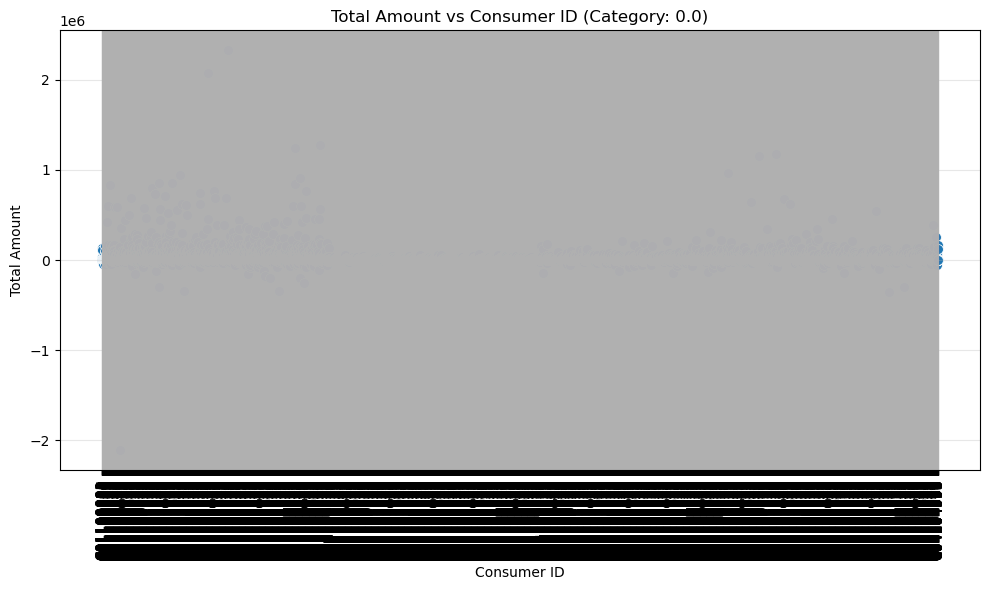

In [14]:
# my_df.groupby(['masked_consumer_id', 'category'])['amount'].sum().reset_index()
import matplotlib.pyplot as plt
import seaborn as sns

# First, get the grouped sum:
grouped_sum = my_df.groupby(['masked_consumer_id', 'category'], as_index=False)['amount'].sum()

# Unique categories
categories = grouped_sum['category'].unique()

# Plot for each category separately
for cat in categories[:1]:
    plt.figure(figsize=(10, 6))
    
    # Filter the data for current category
    data_cat = grouped_sum[grouped_sum['category'] == cat]
    
    # Scatter plot
    sns.scatterplot(
        x='masked_consumer_id',
        y='amount',
        data=data_cat,
        s=50
    )
    
    # Enhance the plot
    plt.title(f'Total Amount vs Consumer ID (Category: {cat})')
    plt.xlabel('Consumer ID')
    plt.ylabel('Total Amount')
    plt.xticks(rotation=90)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    
    # Show plot
    plt.show()


In [13]:
grouped_sum = my_df.groupby(['masked_consumer_id', 'category'], as_index=False)['amount'].sum()

# Unique categories
categories = grouped_sum['category'].unique()
categories[0]

0.0

In [20]:
grouped_sum['amount'].min()
grouped_sum[grouped_sum['amount'] == grouped_sum['amount'].min()]

,masked_consumer_id,category,amount
291135,C04102832,19.0,-7899688.52


In [22]:
my_df[my_df['masked_consumer_id'] == 'C04102832']

,masked_consumer_id,posted_date,amount,category,masked_transaction_id,evaluation_date,FPF_TARGET,total_balance,evaluation_day,posted_day
4409406,C04102832,2021-11-15,400.00,1.0,C04T03810756,2022-11-03,0.0,445260.73,3,0
4409407,C04102832,2021-11-18,1000.00,1.0,C04T03810757,2022-11-03,0.0,445260.73,3,3
4409408,C04102832,2021-12-01,400.00,1.0,C04T03810758,2022-11-03,0.0,445260.73,3,2
4409409,C04102832,2021-12-13,200.00,1.0,C04T03810759,2022-11-03,0.0,445260.73,3,0
4409410,C04102832,2021-12-16,300.00,1.0,C04T03810760,2022-11-03,0.0,445260.73,3,3
...,...,...,...,...,...,...,...,...,...,...
4412696,C04102832,2022-11-02,-2089.00,19.0,C04T03814046,2022-11-03,0.0,445260.73,3,2
4412697,C04102832,2022-11-02,-933.80,19.0,C04T03814047,2022-11-03,0.0,445260.73,3,2
4412698,C04102832,2022-11-02,-28200.00,19.0,C04T03814048,2022-11-03,0.0,445260.73,3,2
4412699,C04102832,2022-11-02,-3309.70,19.0,C04T03814049,2022-11-03,0.0,445260.73,3,2


<Axes: xlabel='category', ylabel='amount'>

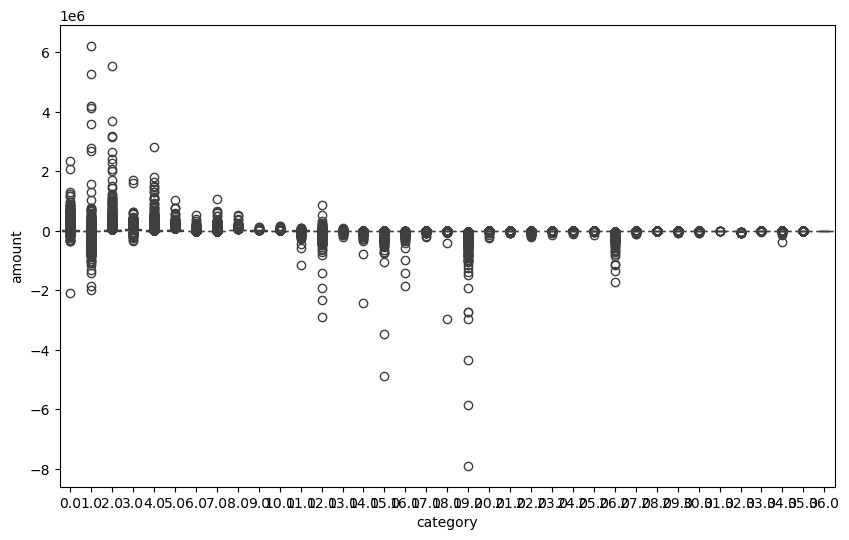

In [16]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=grouped_sum, x='category', y='amount')


<Axes: xlabel='category', ylabel='amount'>

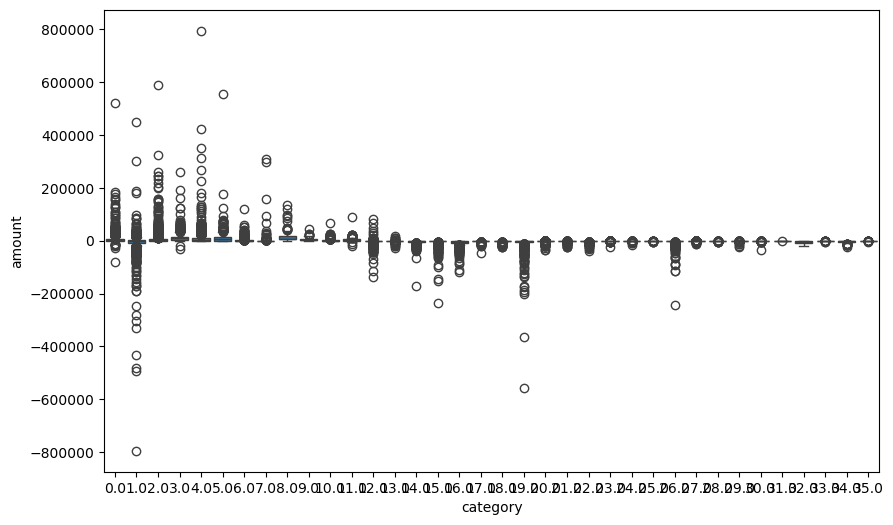

In [23]:
df_default = my_df[my_df['FPF_TARGET'] == 1]
grouped_sum_default = df_default.groupby(['masked_consumer_id', 'category'], as_index=False)['amount'].sum()
plt.figure(figsize=(10, 6))
sns.boxplot(data=grouped_sum_default, x='category', y='amount')

In [15]:
aggregated_data

,masked_consumer_id,num_transactions,total_amount,fin_balance,total_pos_amount,total_neg_amount,mean_pos_amount,mean_neg_amount,mean_amount,amount_mean_median_diff,...,max_amount,common_category,date,first_date_posted,last_date_posted,range_date_posted,mode_day_posted,mean_date_posted,date_mean_median_diff_posted,FPF_TARGET
0,C01100001,2658.0,-8111.42,1380.84,276864.26,-284975.68,896.000841,-121.317871,-3.051701,22.328299,...,8483.00,16.0,1.629936e+09,1.598486e+09,1.629850e+09,363.0,0.0,1.613547e+09,-2.0,0.0
1,C01100002,2489.0,-9490.73,20163.90,285876.77,-295367.50,904.673323,-135.926139,-3.813070,21.476930,...,20000.00,14.0,1.659398e+09,1.627949e+09,1.659312e+09,363.0,0.0,1.643459e+09,-3.0,0.0
2,C01100003,663.0,2137.77,3986.25,84178.75,-82040.98,758.367117,-148.624964,3.224389,24.574389,...,4409.40,14.0,1.614816e+09,1.583366e+09,1.614643e+09,362.0,0.0,1.599471e+09,6.0,0.0
3,C01100004,1084.0,-29837.87,5956.03,97426.62,-127264.49,402.589339,-151.145475,-27.525710,0.029290,...,1748.00,1.0,1.668816e+09,1.637539e+09,1.668730e+09,361.0,0.0,1.652064e+09,13.0,0.0
4,C01100005,2412.0,-9756.37,29421.10,404922.85,-414679.22,787.787646,-218.482202,-4.044930,21.035070,...,39915.16,1.0,1.637453e+09,1.606090e+09,1.637280e+09,361.0,0.0,1.621561e+09,-3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15870,C04104996,769.0,-6255.18,1412.80,34087.79,-40342.97,366.535376,-59.678950,-8.134174,11.855826,...,2000.00,16.0,1.680221e+09,1.649203e+09,1.680134e+09,358.0,0.0,1.665541e+09,0.0,0.0
15871,C04104997,1147.0,-821.02,-439.21,51369.16,-52190.18,634.187160,-48.958893,-0.715798,16.404202,...,4559.67,16.0,1.680221e+09,1.649203e+09,1.680134e+09,358.0,0.0,1.664358e+09,-8.0,0.0
15872,C04104998,1826.0,-1823.87,84.53,93807.66,-95631.53,1321.234648,-54.490900,-0.998834,19.536166,...,6199.20,14.0,1.680221e+09,1.649203e+09,1.680134e+09,358.0,0.0,1.664257e+09,-2.0,0.0
15873,C04104999,1491.0,-18797.57,52655.88,429709.98,-448507.55,1909.822133,-354.271367,-12.607357,12.392643,...,25000.00,14.0,1.680221e+09,1.649203e+09,1.680134e+09,358.0,0.0,1.663693e+09,-6.0,0.0
